In [1]:
import networkx as nx
import numpy as np
import ot
import random
import matplotlib.pyplot as plt
from gwgraphs import *

In [2]:
## CITATION ###
# https://github.com/Gorgotha/LGW #
# lgw_procedure, LGW_graph, and LGW_eucl are taken directly from this code. k_folds_glgw_knn is a modified function from the above code. Everything else is my work. #
np.random.seed(42)
random.seed(42)

In [3]:
# Generate ERSBM1
prob_matrix = [
    [0.15, 0.05],  # Probabilities related to block 1 connections
    [0.05, 0.15]  # Probabilities related to block 2 connections
]

graphs_er = generate_erdos_renyi_graphs(100, 100, 0.1)
graphs_sbm = generate_sbm_graphs(100, [50, 50], prob_matrix)

full_graph_data = graphs_er + graphs_sbm
# Convert graphs to pairwise distance matrices
distance_matrices = [
    compute_distance_matrix(graph) for graph, label in full_graph_data
]
# Prepare labels
labels = [label for graph, label in full_graph_data]

# Normalize the matrices
Ms = []
for matrix in distance_matrices:
    Ms.append(matrix / np.max(matrix))

# Prepare labels
labels = [label for graph, label in full_graph_data]

In [4]:
# Run ERSBM1 Experiment
k_bary = 100
heights = [
    np.full(len(graph), 1 / len(graph)) for graph, label in full_graph_data
]
num_folds = 10

print("Results, Experiments 1")
class_acc_dict, by_class_acc_dict, f1_score_dict, best_k_info = k_folds_glgw_knn(distance_matrices,
            labels,
            k_bary,
            Ms,
            heights,
            num_folds,
            seed=42,
            k_knn_list=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
            method="kfold")

Results, Experiments 1
k-fold CV selected
Fold 0:
Time taken for reference barycenter computation: 3.1342 seconds
Time taken for LGW computation: 2.0018 seconds
k=1, Class 1 Accuracy: 90.0%
k=1, Class -1 Accuracy: 10.0%
k=1, Overall Classification Accuracy: 50.0%
k=1, F1 Score (macro avg): 40.48%
k=2, Class 1 Accuracy: 90.0%
k=2, Class -1 Accuracy: 10.0%
k=2, Overall Classification Accuracy: 50.0%
k=2, F1 Score (macro avg): 40.48%
k=3, Class 1 Accuracy: 100.0%
k=3, Class -1 Accuracy: 10.0%
k=3, Overall Classification Accuracy: 55.00000000000001%
k=3, F1 Score (macro avg): 43.57%
k=4, Class 1 Accuracy: 90.0%
k=4, Class -1 Accuracy: 10.0%
k=4, Overall Classification Accuracy: 50.0%
k=4, F1 Score (macro avg): 40.48%
k=5, Class 1 Accuracy: 100.0%
k=5, Class -1 Accuracy: 0.0%
k=5, Overall Classification Accuracy: 50.0%
k=5, F1 Score (macro avg): 33.33%
k=6, Class 1 Accuracy: 100.0%
k=6, Class -1 Accuracy: 0.0%
k=6, Overall Classification Accuracy: 50.0%
k=6, F1 Score (macro avg): 33.33%
k=7

In [5]:
# Generate ERSBM2
prob_matrix5 = [
    [0.45, 0.05],  # Probabilities related to block 1 connections
    [0.05, 0.45]  # Probabilities related to block 2 connections
]

graphs_er5 = generate_erdos_renyi_graphs(100, 100, 0.25)
graphs_sbm5 = generate_sbm_graphs(100, [50, 50], prob_matrix5)

full_graph_data5 = graphs_er5 + graphs_sbm5
# Convert graphs to pairwise distance matrices
distance_matrices5 = [
    compute_distance_matrix(graph) for graph, label in full_graph_data5
]

# Normalize the matrices
Ms5 = []
for matrix in distance_matrices5:
    Ms5.append(matrix / np.max(matrix))

# Prepare labels
labels5 = [label for graph, label in full_graph_data5]

In [6]:
print("Results, Experiments 2")
class_acc_dict2, by_class_acc_dict2, f1_score_dict2, best_k_info2 = k_folds_glgw_knn(distance_matrices5,
            labels5,
            k_bary,
            Ms5,
            heights,
            num_folds,
            seed=42,
            k_knn_list=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
            method="kfold")

Results, Experiments 2
k-fold CV selected
Fold 0:
Time taken for reference barycenter computation: 3.5965 seconds
Time taken for LGW computation: 2.1004 seconds
k=1, Class 1 Accuracy: 100.0%
k=1, Class -1 Accuracy: 0.0%
k=1, Overall Classification Accuracy: 50.0%
k=1, F1 Score (macro avg): 33.33%
k=2, Class 1 Accuracy: 100.0%
k=2, Class -1 Accuracy: 0.0%
k=2, Overall Classification Accuracy: 50.0%
k=2, F1 Score (macro avg): 33.33%
k=3, Class 1 Accuracy: 100.0%
k=3, Class -1 Accuracy: 0.0%
k=3, Overall Classification Accuracy: 50.0%
k=3, F1 Score (macro avg): 33.33%
k=4, Class 1 Accuracy: 100.0%
k=4, Class -1 Accuracy: 0.0%
k=4, Overall Classification Accuracy: 50.0%
k=4, F1 Score (macro avg): 33.33%
k=5, Class 1 Accuracy: 100.0%
k=5, Class -1 Accuracy: 0.0%
k=5, Overall Classification Accuracy: 50.0%
k=5, F1 Score (macro avg): 33.33%
k=6, Class 1 Accuracy: 100.0%
k=6, Class -1 Accuracy: 0.0%
k=6, Overall Classification Accuracy: 50.0%
k=6, F1 Score (macro avg): 33.33%
k=7, Class 1 Accu

In [7]:
### gLGW analysis: GW distances vs. gLGW distances ###
## Code drawn from the source code listed at the beginning. ##

# Pairwise GW distances, ERSBM1
N=200
heights = [
    np.full(len(graph), 1 / len(graph)) for graph, label in full_graph_data
]
gw = np.zeros((N,N))
for i in range(N):
    for j in range(i+1,N):
        tmp = ot.gromov.gromov_wasserstein2(Ms[i],Ms[j],heights[i],heights[j],loss_fun="square_loss",log=True)
        gw[i,j] = tmp[0]
        #Ps_gw[i,j] = tmp[1]["T"]
gw = np.sqrt(gw)
gw += gw.T

# Pairwise gLGW distances, ERSBM1
k_bary = 100
idx_bary = []
classes = [-1,1]
height_ref = ot.unif(k_bary)
for i in classes:
    # Find the indices of instances with label i
    indices = np.where(np.array(labels) == i)[0]
    if indices.size > 0:
        idx_bary.extend(np.random.choice(indices, size=min(5, len(indices)), replace=False))
M_ref = ot.gromov.gromov_barycenters(k_bary,
                                             Cs=np.array(Ms)[idx_bary],
                                             ps=np.array(heights)[idx_bary],
                                             p=ot.unif(k_bary),
                                             lambdas=ot.unif(len(idx_bary)),
                                             loss_fun='square_loss',
                                             max_iter=200,
                                             tol=1e-12,
                                             random_state=42)
lgw1,t1 = lgw_procedure(M_ref,height_ref,None,Ms,heights,mode="graph")

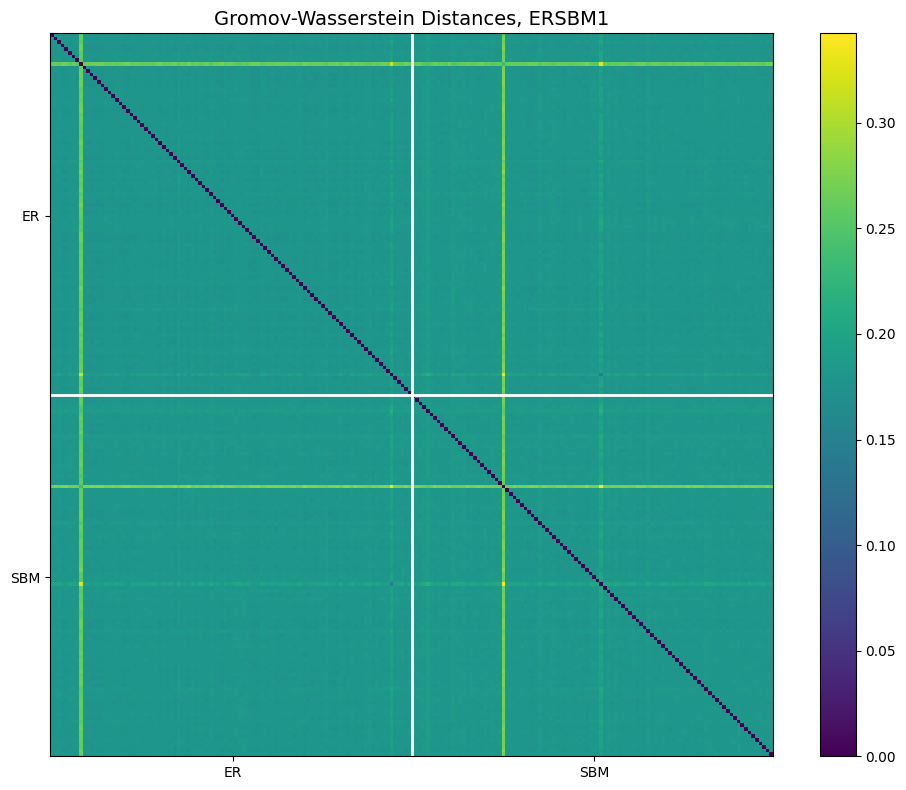

In [8]:
# Create plot for GW distances, ERSBM1
plt.figure(figsize=(10, 8))
plt.title('Gromov-Wasserstein Distances, ERSBM1', fontsize=14)

# Combine all pairwise distances in one plot
im_gw = plt.imshow(gw, cmap='viridis')
plt.colorbar(im_gw)

# Set ticks and labels
ticks = [50, 150]
plt.xticks(ticks, ['ER', 'SBM'])
plt.yticks(ticks, ['ER', 'SBM'])

# Add grid lines to separate the quadrants
plt.axvline(x=99.5, color='white', linewidth=2)
plt.axhline(y=99.5, color='white', linewidth=2)

plt.tight_layout()
plt.show()

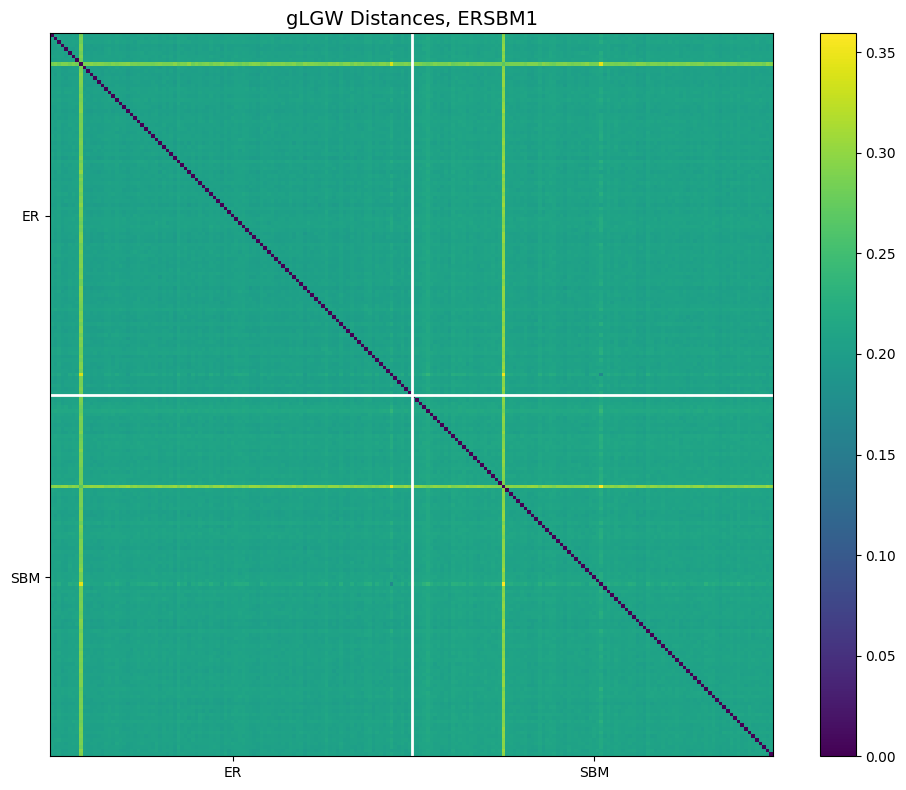

In [9]:
# Create plot for gLGW distances, ERSBM1
plt.figure(figsize=(10, 8))
plt.title('gLGW Distances, ERSBM1', fontsize=14)

# Combine all pairwise distances in one plot
im_lgw = plt.imshow(lgw1, cmap='viridis')
plt.colorbar(im_lgw)

# Set ticks and labels
ticks = [50, 150]
plt.xticks(ticks, ['ER', 'SBM'])
plt.yticks(ticks, ['ER', 'SBM'])

# Add grid lines to separate the quadrants
plt.axvline(x=99.5, color='white', linewidth=2)
plt.axhline(y=99.5, color='white', linewidth=2)

plt.tight_layout()
plt.show()

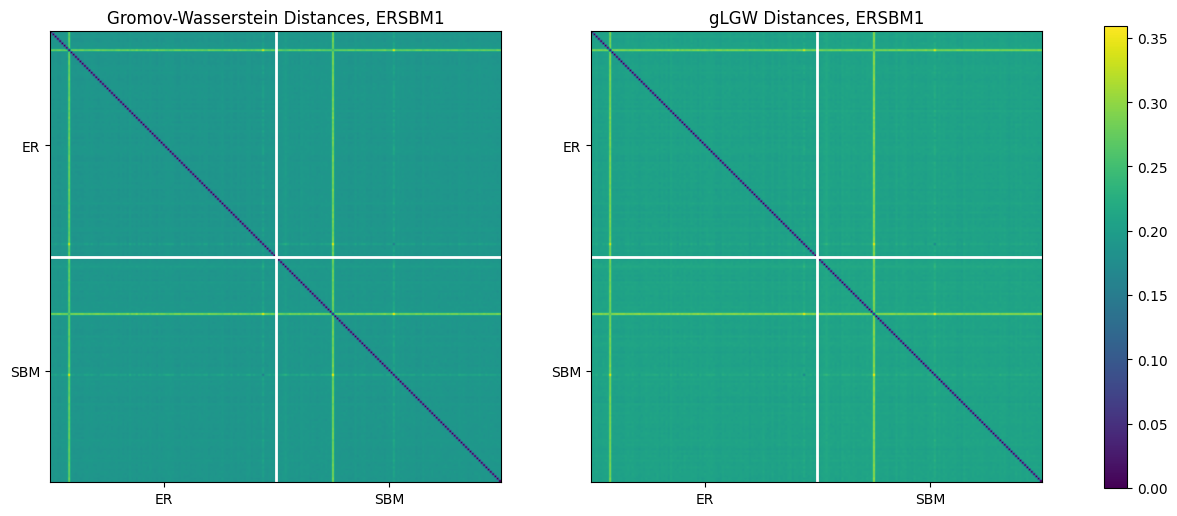

In [10]:
# ERSBM1
# Create figure with two subfigures
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot GW distances
im_gw = ax1.imshow(gw, cmap='viridis')
ax1.set_title('Gromov-Wasserstein Distances, ERSBM1', fontsize=12)
ticks = [50, 150]
ax1.set_xticks(ticks, ['ER', 'SBM'])
ax1.set_yticks(ticks, ['ER', 'SBM'])
ax1.axvline(x=99.5, color='white', linewidth=2)
ax1.axhline(y=99.5, color='white', linewidth=2)

# Plot gLGW distances
im_lgw = ax2.imshow(lgw1, cmap='viridis', vmin=min(gw.min(), lgw1.min()), vmax=max(gw.max(), lgw1.max()))
ax2.set_title('gLGW Distances, ERSBM1', fontsize=12)
ax2.set_xticks(ticks, ['ER', 'SBM'])
ax2.set_yticks(ticks, ['ER', 'SBM'])
ax2.axvline(x=99.5, color='white', linewidth=2)
ax2.axhline(y=99.5, color='white', linewidth=2)

# Add shared colorbar
fig.colorbar(im_lgw, ax=(ax1, ax2))

In [11]:
# Pairwise GW distances, ERSBM2
N=200
heights5 = [
    np.full(len(graph), 1 / len(graph)) for graph, label in full_graph_data5
]
gw5 = np.zeros((N,N))
for i in range(N):
    for j in range(i+1,N):
        tmp = ot.gromov.gromov_wasserstein2(Ms5[i],Ms5[j],heights[i],heights[j],loss_fun="square_loss",log=True)
        gw5[i,j] = tmp[0]
        #Ps_gw[i,j] = tmp[1]["T"]
gw5 = np.sqrt(gw5)
gw5 += gw5.T

# Pairwise gLGW distances, ERSBM2
k_bary = 100
idx_bary5 = []
classes = [-1,1]
height_ref5 = ot.unif(k_bary)
for i in classes:
    # Find the indices of instances with label i
    indices5 = np.where(np.array(labels5) == i)[0]
    if indices.size > 0:
        idx_bary5.extend(np.random.choice(indices5, size=min(5, len(indices5)), replace=False))
M_ref5 = ot.gromov.gromov_barycenters(k_bary,
                                             Cs=np.array(Ms5)[idx_bary],
                                             ps=np.array(heights)[idx_bary],
                                             p=ot.unif(k_bary),
                                             lambdas=ot.unif(len(idx_bary5)),
                                             loss_fun='square_loss',
                                             max_iter=200,
                                             tol=1e-12,
                                             random_state=42)
lgw5,t5 = lgw_procedure(M_ref5,height_ref5,None,Ms5,heights,mode="graph")

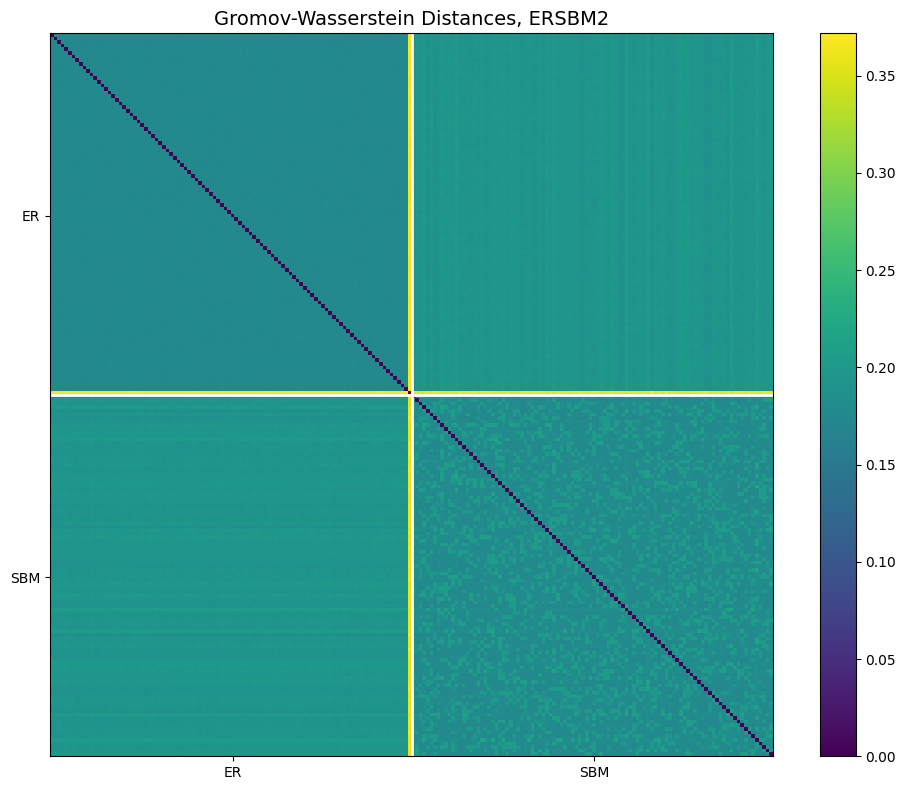

In [12]:
# Create plot for GW distances, ERSBM2
plt.figure(figsize=(10, 8))
plt.title('Gromov-Wasserstein Distances, ERSBM2', fontsize=14)

# Combine all pairwise distances in one plot
im_gw = plt.imshow(gw5, cmap='viridis')
plt.colorbar(im_gw)

# Set ticks and labels
ticks = [50, 150]
plt.xticks(ticks, ['ER', 'SBM'])
plt.yticks(ticks, ['ER', 'SBM'])

# Add grid lines to separate the quadrants
plt.axvline(x=99.5, color='white', linewidth=2)
plt.axhline(y=99.5, color='white', linewidth=2)

plt.tight_layout()
plt.show()

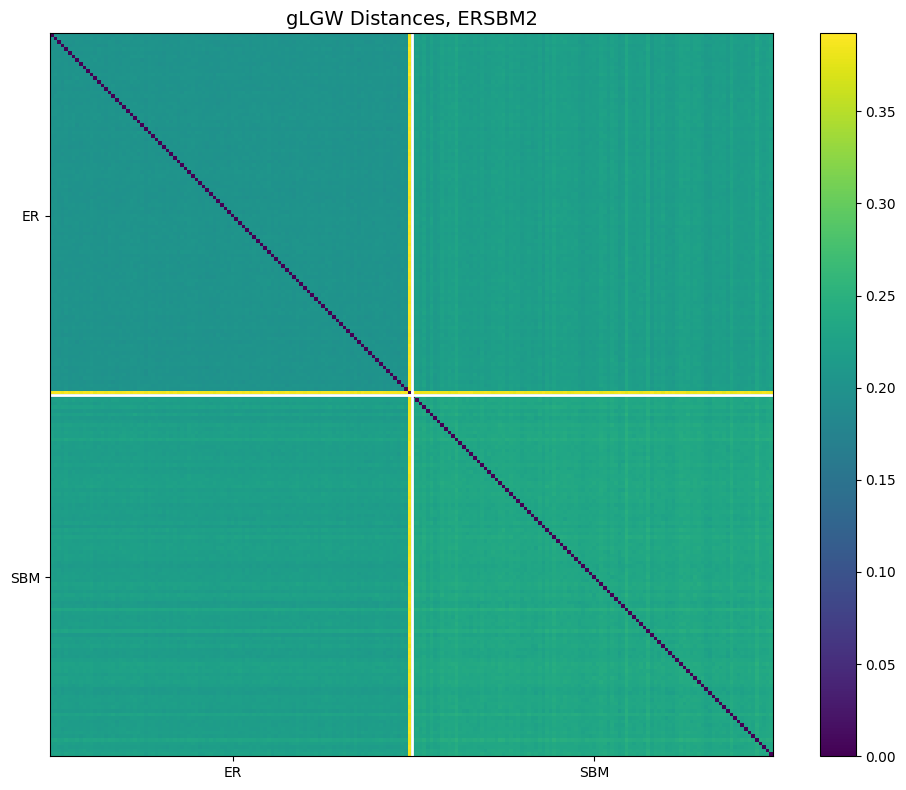

In [13]:
# Create plot for gLGW distances, ERSBM2
plt.figure(figsize=(10, 8))
plt.title('gLGW Distances, ERSBM2', fontsize=14)

# Combine all pairwise distances in one plot
im_lgw = plt.imshow(lgw5, cmap='viridis')
plt.colorbar(im_lgw)

# Set ticks and labels
ticks = [50, 150]
plt.xticks(ticks, ['ER', 'SBM'])
plt.yticks(ticks, ['ER', 'SBM'])

# Add grid lines to separate the quadrants
plt.axvline(x=99.5, color='white', linewidth=2)
plt.axhline(y=99.5, color='white', linewidth=2)

plt.tight_layout()
plt.show()

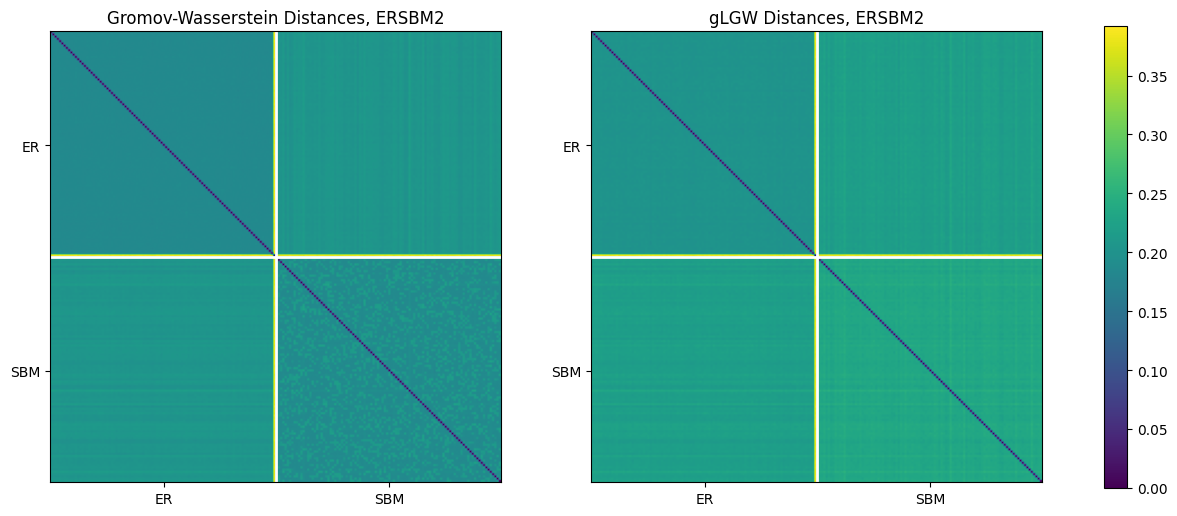

In [14]:
# ERSBM2
# Create figure with two subfigures
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot GW distances
im_gw = ax1.imshow(gw5, cmap='viridis')
ax1.set_title('Gromov-Wasserstein Distances, ERSBM2', fontsize=12)
ticks = [50, 150]
ax1.set_xticks(ticks, ['ER', 'SBM'])
ax1.set_yticks(ticks, ['ER', 'SBM'])
ax1.axvline(x=99.5, color='white', linewidth=2)
ax1.axhline(y=99.5, color='white', linewidth=2)

# Plot gLGW distances
im_lgw = ax2.imshow(lgw5, cmap='viridis', vmin=min(gw5.min(), lgw5.min()), vmax=max(gw5.max(), lgw5.max()))
ax2.set_title('gLGW Distances, ERSBM2', fontsize=12)
ax2.set_xticks(ticks, ['ER', 'SBM'])
ax2.set_yticks(ticks, ['ER', 'SBM'])
ax2.axvline(x=99.5, color='white', linewidth=2)
ax2.axhline(y=99.5, color='white', linewidth=2)

# Add shared colorbar
fig.colorbar(im_lgw, ax=(ax1, ax2))

In [15]:
def remove_diag(x):
    x_no_diag = np.ndarray.flatten(x)
    x_no_diag = np.delete(x_no_diag, range(0, len(x_no_diag), len(x) + 1), 0)
    x_no_diag = x_no_diag.reshape(len(x), len(x) - 1)
    return x_no_diag

In [16]:
gw_nozeros = remove_diag(gw)
lgw1_nozeros = remove_diag(lgw1)
gw5_nozeros = remove_diag(gw5)
lgw5_nozeros = remove_diag(lgw5)

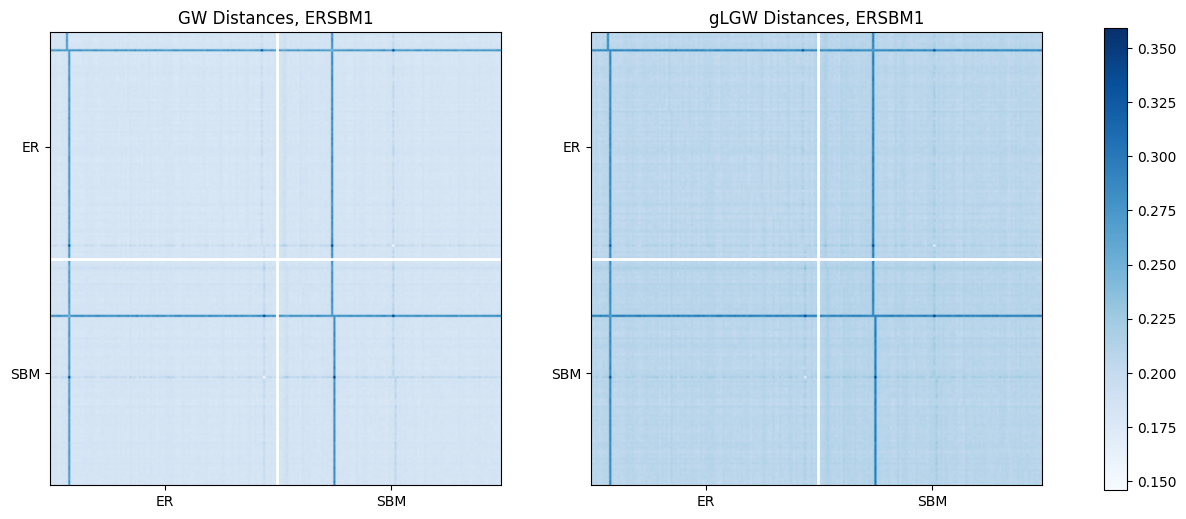

In [17]:
# ERSBM1, no diagonal of zeros
# Create figure with two subfigures
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot GW distances
im_gw = ax1.imshow(gw_nozeros, cmap='Blues')
ax1.set_title('GW Distances, ERSBM1', fontsize=12)
ticks = [50, 150]
ax1.set_xticks(ticks, ['ER', 'SBM'])
ax1.set_yticks(ticks, ['ER', 'SBM'])
ax1.axvline(x=99.5, color='white', linewidth=2)
ax1.axhline(y=99.5, color='white', linewidth=2)

# Plot gLGW distances
im_lgw = ax2.imshow(lgw1_nozeros, cmap='Blues', vmin=min(gw_nozeros.min(), lgw1_nozeros.min()), vmax=max(gw_nozeros.max(), lgw1_nozeros.max()))
ax2.set_title('gLGW Distances, ERSBM1', fontsize=12)
ax2.set_xticks(ticks, ['ER', 'SBM'])
ax2.set_yticks(ticks, ['ER', 'SBM'])
ax2.axvline(x=99.5, color='white', linewidth=2)
ax2.axhline(y=99.5, color='white', linewidth=2)

# Add shared colorbar
fig.colorbar(im_lgw, ax=(ax1, ax2))

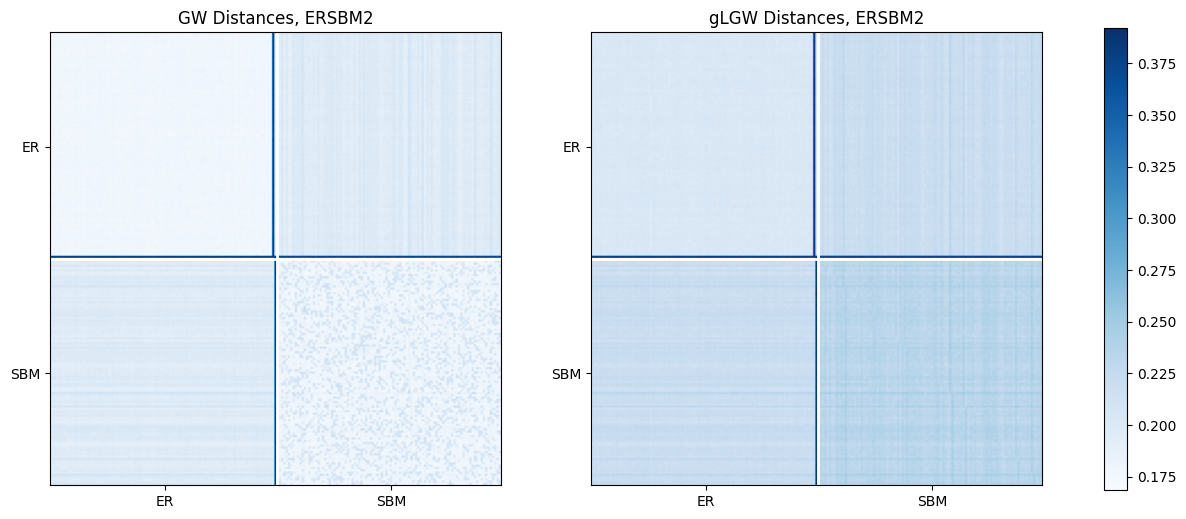

In [18]:
# ERSBM2, no diagonal of zeros
# Create figure with two subfigures
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot GW distances
im_gw = ax1.imshow(gw5_nozeros, cmap='Blues')
ax1.set_title('GW Distances, ERSBM2', fontsize=12)
ticks = [50, 150]
ax1.set_xticks(ticks, ['ER', 'SBM'])
ax1.set_yticks(ticks, ['ER', 'SBM'])
ax1.axvline(x=99.5, color='white', linewidth=2)
ax1.axhline(y=99.5, color='white', linewidth=2)

# Plot gLGW distances
im_lgw = ax2.imshow(lgw5_nozeros, cmap='Blues', vmin=min(gw5_nozeros.min(), lgw5_nozeros.min()), vmax=max(gw5_nozeros.max(), lgw5_nozeros.max()))
ax2.set_title('gLGW Distances, ERSBM2', fontsize=12)
ax2.set_xticks(ticks, ['ER', 'SBM'])
ax2.set_yticks(ticks, ['ER', 'SBM'])
ax2.axvline(x=99.5, color='white', linewidth=2)
ax2.axhline(y=99.5, color='white', linewidth=2)

# Add shared colorbar
fig.colorbar(im_lgw, ax=(ax1, ax2))

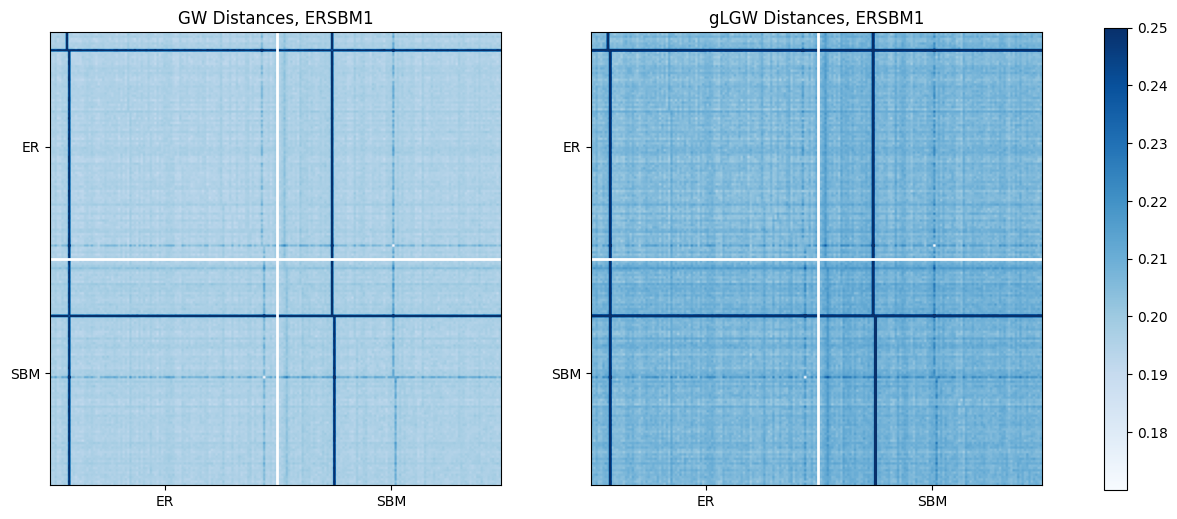

In [19]:
# ERSBM1, no diagonal of zeros, different colorbar thresholding
# Create figure with two subfigures
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot GW distances
im_gw = ax1.imshow(gw_nozeros, cmap='Blues', vmax=0.25)
ax1.set_title('GW Distances, ERSBM1', fontsize=12)
ticks = [50, 150]
ax1.set_xticks(ticks, ['ER', 'SBM'])
ax1.set_yticks(ticks, ['ER', 'SBM'])
ax1.axvline(x=99.5, color='white', linewidth=2)
ax1.axhline(y=99.5, color='white', linewidth=2)

# Plot gLGW distances
im_lgw = ax2.imshow(lgw1_nozeros, cmap='Blues', vmax=0.25)
ax2.set_title('gLGW Distances, ERSBM1', fontsize=12)
ax2.set_xticks(ticks, ['ER', 'SBM'])
ax2.set_yticks(ticks, ['ER', 'SBM'])
ax2.axvline(x=99.5, color='white', linewidth=2)
ax2.axhline(y=99.5, color='white', linewidth=2)

# Add shared colorbar
fig.colorbar(im_lgw, ax=(ax1, ax2))

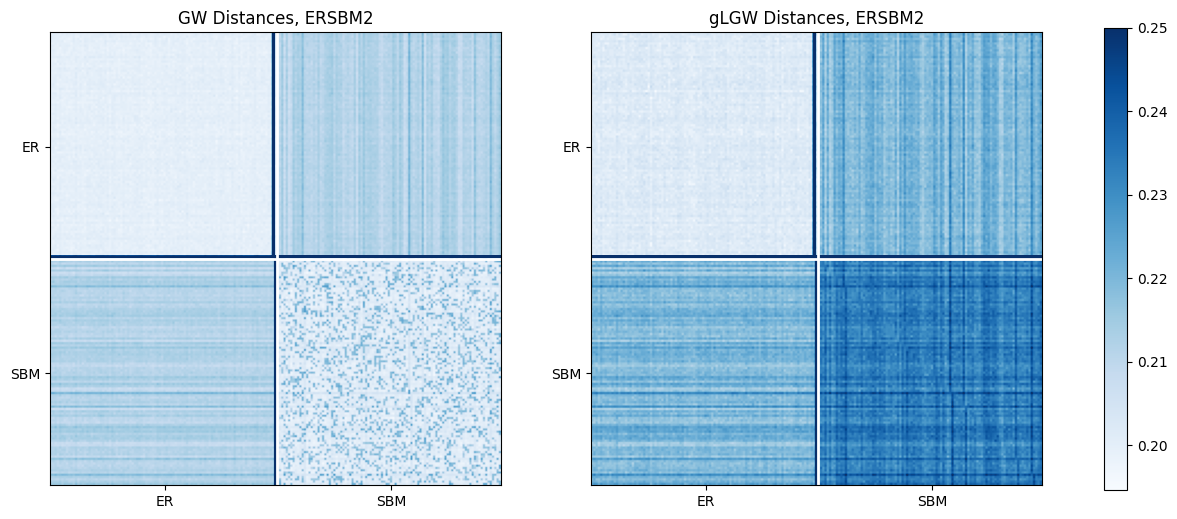

In [20]:
# ERSBM2, no diagonal of zeros, different colorbar thresholding
# Create figure with two subfigures
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot GW distances
im_gw = ax1.imshow(gw5_nozeros, cmap='Blues', vmax=0.25)
ax1.set_title('GW Distances, ERSBM2', fontsize=12)
ticks = [50, 150]
ax1.set_xticks(ticks, ['ER', 'SBM'])
ax1.set_yticks(ticks, ['ER', 'SBM'])
ax1.axvline(x=99.5, color='white', linewidth=2)
ax1.axhline(y=99.5, color='white', linewidth=2)

# Plot gLGW distances
im_lgw = ax2.imshow(lgw5_nozeros, cmap='Blues', vmax=0.25)
ax2.set_title('gLGW Distances, ERSBM2', fontsize=12)
ax2.set_xticks(ticks, ['ER', 'SBM'])
ax2.set_yticks(ticks, ['ER', 'SBM'])
ax2.axvline(x=99.5, color='white', linewidth=2)
ax2.axhline(y=99.5, color='white', linewidth=2)

# Add shared colorbar
fig.colorbar(im_lgw, ax=(ax1, ax2))